# Differentially Private DNN - Kidney Stone Risk Prediction Dataset

**Method**: DP-SGD via [Opacus](https://opacus.ai/)

Per-sample gradient clipping + Gaussian noise (Rényi DP accounting).

In [1]:
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import pickle, json, os
import warnings; warnings.filterwarnings("ignore")
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


W0811 11:16:33.964000 306 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Device: cpu


In [2]:
with open("../data/processed_data.pkl","rb") as f: loaded_data = pickle.load(f)
X_train=loaded_data["X_train"]; X_test=loaded_data["X_test"]
y_train=loaded_data["y_train"]; y_test=loaded_data["y_test"]
print(f"Training: {X_train.shape} | Test: {X_test.shape}")

X_train_t=torch.FloatTensor(X_train); y_train_t=torch.LongTensor(y_train)
X_test_t=torch.FloatTensor(X_test); y_test_t=torch.LongTensor(y_test)

# Adaptive DP-SGD batch size (D13): scales with training-set size,
# clamped to [16, 256] so small datasets keep enough steps per epoch
# and large ones stay within Opacus' preferred large-batch regime.
n_train = X_train.shape[0]
batch_size = min(256, max(16, n_train // 8))
print(f"[D13] KIDNEY_STONE: n_train={n_train} -> batch_size={batch_size}")
train_dataset=TensorDataset(X_train_t,y_train_t)
test_loader=DataLoader(TensorDataset(X_test_t,y_test_t),batch_size=64,shuffle=False)
print("Data loaded")


Training: (3200, 23) | Test: (800, 23)
[D13] KIDNEY_STONE: n_train=3200 -> batch_size=256
Data loaded


In [3]:
try:
    baseline_df=pd.read_csv("output/baseline_results.csv")
    baseline_accuracy=baseline_df["accuracy"].values[0]; baseline_f1=baseline_df["f1_score"].values[0]
    print(f"Baseline Accuracy: {baseline_accuracy:.4f} | F1: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: Run STD_DNN.ipynb first."); baseline_accuracy=None; baseline_f1=None


Baseline Accuracy: 0.9728 | F1: 0.9655


In [4]:
class DPDNNClassifier(nn.Module):
    def __init__(self,input_size=23,hidden_sizes=[64,32],num_classes=2,dropout=0.3):
        super().__init__()
        layers=[]; prev=input_size
        for h in hidden_sizes:
            layers+=[nn.Linear(prev,h),nn.ReLU(),nn.Dropout(dropout)]; prev=h
        layers.append(nn.Linear(prev,num_classes))
        self.network=nn.Sequential(*layers)
    def forward(self,x): return self.network(x)

input_size=X_train.shape[1]; hidden_sizes=[64,32]; num_classes=2; dropout=0.3
lr_rate=0.001; num_epochs=50
print(f"DP-DNN Architecture: Input({input_size}) -> Dense(64) -> Dense(32) -> Output(2)")


DP-DNN Architecture: Input(23) -> Dense(64) -> Dense(32) -> Output(2)


In [5]:
def train_dp_model(model,train_loader,criterion,optimizer,privacy_engine,epochs,device,delta,verbose=False):
    model.train(); losses=[]; epsilons=[]
    for epoch in range(epochs):
        ep_loss=0.0
        for x,y in train_loader:
            x,y=x.to(device),y.to(device); out=model(x); loss=criterion(out,y)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_loss+=loss.item()
        avg=ep_loss/len(train_loader); losses.append(avg)
        eps=privacy_engine.get_epsilon(delta=delta); epsilons.append(eps)
        if verbose and (epoch+1)%10==0: print(f"  Epoch [{epoch+1}/{epochs}], Loss: {avg:.4f}, \u03b5: {eps:.2f}")
    return losses, epsilons

def evaluate_model(model, loader, device):
    """Return (labels, predictions, class probabilities) for `loader`.

    The probabilities are what AUROC needs; predictions and labels are
    unchanged from the original implementation.
    """
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
            all_preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("Functions defined")


Functions defined


In [6]:
N_RUNS=30; max_grad_norm=1.0; delta=1e-5
epsilon_values=[0.1,0.2,0.4,0.8,1.0,2.0,4.0,8.0,10.0]
print(f"Privacy Config: \u03b4={delta:.1e}, max_grad_norm={max_grad_norm}, epochs={num_epochs}")
print(f"Epsilon values: {epsilon_values}")
print(f"N_RUNS: {N_RUNS}")


Privacy Config: δ=1.0e-05, max_grad_norm=1.0, epochs=50
Epsilon values: [0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0]
N_RUNS: 30


In [7]:
results_json={"model_type":"DP-DNN (Opacus)","dataset":"Kidney Stone Risk Prediction Dataset","privacy_mechanism":"DP-SGD","parameters":{"hidden_sizes":hidden_sizes,"dropout":dropout,"lr":lr_rate,"max_grad_norm":max_grad_norm,"delta":delta,"epochs":num_epochs,"batch_size":batch_size,"n_runs":N_RUNS},"epsilon_results":{}}
results={"epsilon":[],"accuracy_mean":[],"accuracy_std":[],"f1_score_mean":[],"f1_score_std":[],"precision_mean":[],"recall_mean":[]}
print(f"Training DP-DNN across {len(epsilon_values)} epsilon values ({N_RUNS} runs each)...")
print("="*80)
for target_eps in epsilon_values:
    run_accs=[]; run_f1s=[]; run_precs=[]; run_recs=[]
    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed=run*10+42; torch.manual_seed(seed); np.random.seed(seed)
        if torch.cuda.is_available(): torch.cuda.manual_seed(seed)
        tl=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
        model=DPDNNClassifier(input_size,hidden_sizes,num_classes,dropout).to(device)
        model=ModuleValidator.fix(model)
        criterion=nn.CrossEntropyLoss(); optimizer=optim.Adam(model.parameters(),lr=lr_rate)
        pe=PrivacyEngine()
        model,optimizer,tl=pe.make_private_with_epsilon(module=model,optimizer=optimizer,data_loader=tl,target_epsilon=target_eps,target_delta=delta,epochs=num_epochs,max_grad_norm=max_grad_norm)
        if isinstance(optimizer.noise_multiplier,list): optimizer.noise_multiplier=optimizer.noise_multiplier[0]
        _t0 = time.perf_counter()
        train_dp_model(model,tl,criterion,optimizer,pe,num_epochs,device,delta)
        train_time = time.perf_counter() - _t0
        y_true, y_pred, y_prob = evaluate_model(model,test_loader,device)
        run_accs.append(accuracy_score(y_true,y_pred)); run_f1s.append(f1_score(y_true,y_pred,zero_division=0))
        extra.add(y_true, y_pred, y_score=y_prob, train_time=train_time)
        run_precs.append(precision_score(y_true,y_pred,zero_division=0)); run_recs.append(recall_score(y_true,y_pred,zero_division=0))
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(model, f'output/model/dp_dnn_model_eps_{target_eps}.pt')
    acc_m,acc_s=np.mean(run_accs),np.std(run_accs); f1_m,f1_s=np.mean(run_f1s),np.std(run_f1s)
    results["epsilon"].append(target_eps); results["accuracy_mean"].append(acc_m); results["accuracy_std"].append(acc_s)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results["f1_score_mean"].append(f1_m); results["f1_score_std"].append(f1_s)
    results["precision_mean"].append(np.mean(run_precs)); results["recall_mean"].append(np.mean(run_recs))
    results_json["epsilon_results"][str(target_eps)]=dict(epsilon=float(target_eps),n_runs=N_RUNS,accuracy_mean=acc_m,accuracy_std=acc_s,f1_mean=f1_m,f1_std=f1_s,precision_mean=float(np.mean(run_precs)),recall_mean=float(np.mean(run_recs)),per_run_accuracies=run_accs,per_run_f1s=run_f1s)
    results_json["epsilon_results"][str(target_eps)].update(extra.summary())
    results_json["epsilon_results"][str(target_eps)].update(extra.per_run())
    print(f"  \u03b5={target_eps:5.1f} | Acc: {acc_m:.4f}\u00b1{acc_s:.4f} | F1: {f1_m:.4f}\u00b1{f1_s:.4f}")
print("="*80); print("Training complete")


Training DP-DNN across 9 epsilon values (30 runs each)...


PyTorch model successfully exported to output/model/dp_dnn_model_eps_0.1.pt


  ε=  0.1 | Acc: 0.6819±0.0800 | F1: 0.2699±0.2730


PyTorch model successfully exported to output/model/dp_dnn_model_eps_0.2.pt


  ε=  0.2 | Acc: 0.8145±0.0755 | F1: 0.6660±0.2040


...

  ε=  4.0 | Acc: 0.8900±0.0000 | F1: 0.8388±0.0000


PyTorch model successfully exported to output/model/dp_dnn_model_eps_8.0.pt


  ε=  8.0 | Acc: 0.8900±0.0000 | F1: 0.8388±0.0000


PyTorch model successfully exported to output/model/dp_dnn_model_eps_10.0.pt


  ε= 10.0 | Acc: 0.8900±0.0000 | F1: 0.8388±0.0000
Training complete


In [8]:
results_df=pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df["ACL"]=1-(results_df["accuracy_mean"]/baseline_accuracy)
    results_df["accuracy_loss_pct"]=results_df["ACL"]*100
print("\n"+"="*80)
print("DP-DNN RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))



DP-DNN RESULTS SUMMARY
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  recall_mean  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std      ACL  accuracy_loss_pct
     0.1       0.681875  7.997053e-02       0.269869  2.730320e-01        0.721146     0.189137                0.593850           1.026614e-01      0.884185     0.019170         1.946736        0.081562 0.299023          29.902339
     0.2       0.814458  7.553813e-02       0.665965  2.039856e-01        0.987609     0.533440                0.764256           9.719731e-02      0.892924     0.017305         1.969578        0.026703 0.162726          16.272595
     0.4       0.889958  2.243819e-04       0.838757  3.824528e-04        0.982830     0.731523                0.861655           2.867500e-04      0.904473     0.015860         1.995359        0.020740 0.085111           8.511094
     0.8       0.890000  1.110223e-16       0.838828

In [9]:
os.makedirs("output",exist_ok=True)
results_df.to_csv("output/dp_results.csv",index=False)
results_df.to_csv("output/dp_dnn_results.csv",index=False)
with open("output/dp_dnn_report.json","w") as f: json.dump(results_json,f,indent=4)
print("Results saved to output/")


Results saved to output/


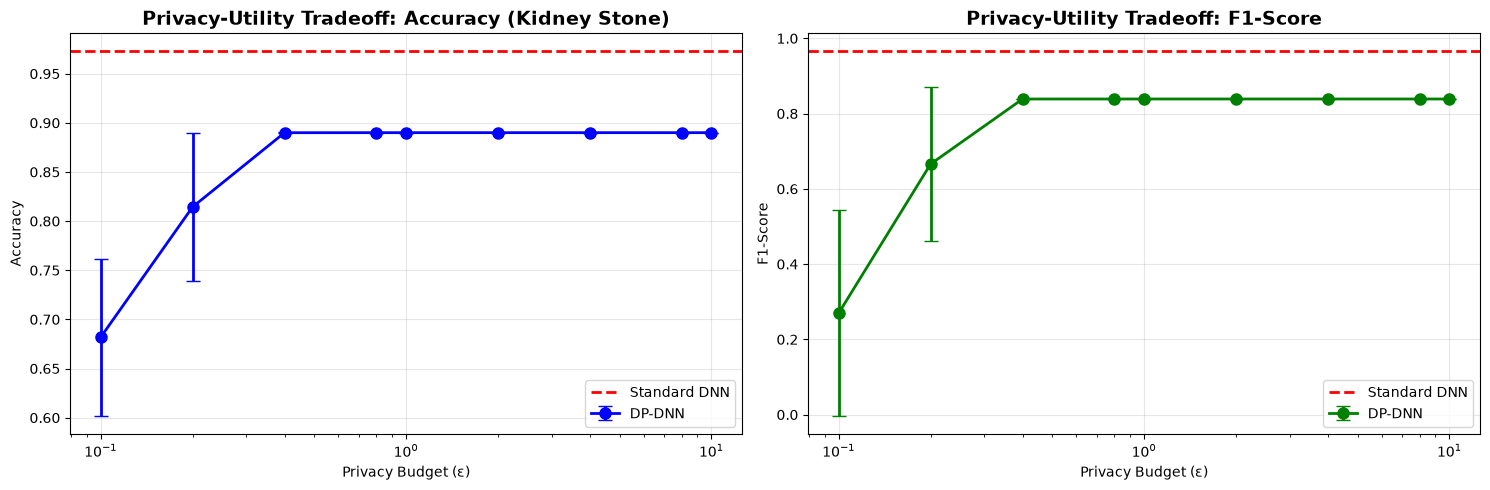

In [10]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
axes[0].errorbar(results_df["epsilon"],results_df["accuracy_mean"],yerr=results_df["accuracy_std"],fmt="bo-",capsize=5,linewidth=2,markersize=8,label="DP-DNN")
if baseline_accuracy: axes[0].axhline(y=baseline_accuracy,color="r",linestyle="--",linewidth=2,label="Standard DNN")
axes[0].set_title("Privacy-Utility Tradeoff: Accuracy (Kidney Stone)",fontsize=14,fontweight="bold")
axes[0].set_xlabel("Privacy Budget (\u03b5)"); axes[0].set_ylabel("Accuracy")
axes[0].set_xscale("log"); axes[0].grid(True,alpha=0.3); axes[0].legend()
axes[1].errorbar(results_df["epsilon"],results_df["f1_score_mean"],yerr=results_df["f1_score_std"],fmt="go-",capsize=5,linewidth=2,markersize=8,label="DP-DNN")
if baseline_f1: axes[1].axhline(y=baseline_f1,color="r",linestyle="--",linewidth=2,label="Standard DNN")
axes[1].set_title("Privacy-Utility Tradeoff: F1-Score",fontsize=14,fontweight="bold")
axes[1].set_xlabel("Privacy Budget (\u03b5)"); axes[1].set_ylabel("F1-Score")
axes[1].set_xscale("log"); axes[1].grid(True,alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.savefig("output/dp_dnn_tradeoff.png",dpi=300,bbox_inches="tight")
plt.show()
